In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
df_nav_history['date'] = pd.to_datetime(df_nav_history['date'])
df_nav_history = df_nav_history.sort_values(['amfi_code', 'date']).reset_index(drop=True)

print("Data loaded. Shape:", df_nav_history.shape)

Data loaded. Shape: (64320, 3)


## Computing daily returns

Daily Returns Summary:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


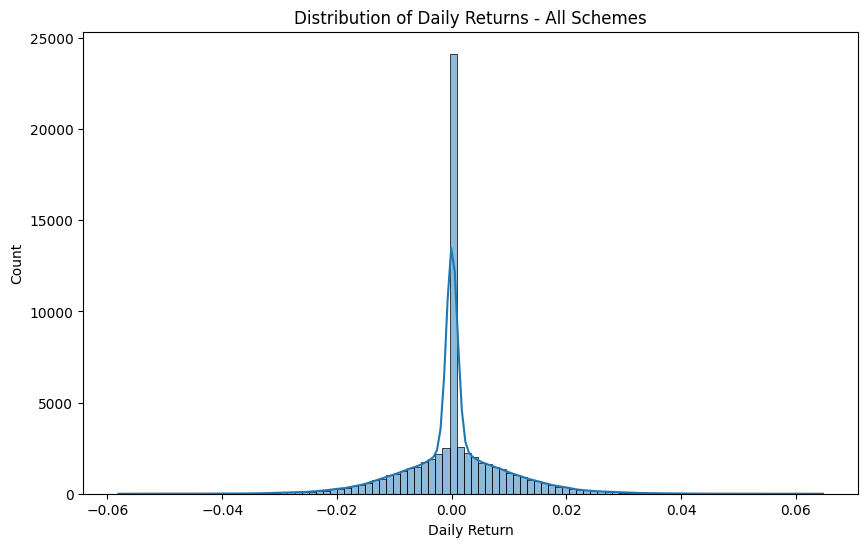

In [8]:
df_nav_history['daily_return'] = df_nav_history.groupby('amfi_code')['nav'].pct_change()

print("Daily Returns Summary:")
print(df_nav_history['daily_return'].describe())

# Distribution check
plt.figure(figsize=(10,6))
sns.histplot(df_nav_history['daily_return'].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns - All Schemes")
plt.xlabel("Daily Return")
plt.show()

In [29]:
df_nav_history['amfi_code'] = df_nav_history['amfi_code'].astype('int')

In [30]:
df_nav_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64320 entries, 0 to 64319
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amfi_code     64320 non-null  int64         
 1   date          64320 non-null  datetime64[ns]
 2   nav           64320 non-null  float64       
 3   daily_return  64280 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 2.0 MB


## CAGR Table

In [15]:
def cagr(group, years):
    group = group.sort_values('date')
    start_nav = group['nav'].iloc[0]
    end_nav = group['nav'].iloc[-1]
    return (end_nav / start_nav) ** (1 / years) - 1

cagr_data = []
for code, group in df_nav_history.groupby('amfi_code'):
    cagr_data.append({
        'amfi_code': code,
        'CAGR_1yr': cagr(group, 1),
        'CAGR_3yr': cagr(group, 3),
        'CAGR_5yr': cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_data)
cagr_df['amfi_code'] = cagr_df['amfi_code'].astype('int')

In [16]:
print("Top 10 Funds by 3-Year CAGR:")
print(cagr_df.sort_values('CAGR_3yr', ascending=False).head(10).round(4))

Top 10 Funds by 3-Year CAGR:
    amfi_code  CAGR_1yr  CAGR_3yr  CAGR_5yr
25     120505    2.4868    0.5164    0.2838
21     119598    2.4404    0.5096    0.2803
39     149324    2.4249    0.5074    0.2792
36     148569    2.3866    0.5017    0.2763
34     148567    2.2778    0.4855    0.2680
30     120843    2.2705    0.4844    0.2674
2      100033    2.1851    0.4713    0.2607
38     149323    2.1272    0.4623    0.2561
16     119094    1.9846    0.4398    0.2445
19     119551    1.7456    0.4003    0.2238


## Sharpe and Sortino Ratio

In [64]:
Rf_daily  = 0.065 / 252  

def sharpe_ratio(group):
    return (group.mean() - Rf_daily ) / group.std() * np.sqrt(252) if group.std() != 0 else np.nan

def sortino_ratio(group):
    downside = group[group < 0]
    return (group.mean() - Rf_daily ) / downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan

df_nav_ratio_compiled = df_nav_history.groupby('amfi_code')['daily_return'].agg([sharpe_ratio, sortino_ratio]).reset_index()
df_nav_ratio_compiled = df_nav_ratio_compiled.rename(columns={'sharpe_ratio': 'Sharpe', 'sortino_ratio': 'Sortino'})
print(metrics.sort_values('Sharpe', ascending=False).head(10))

    amfi_code    Sharpe   Sortino
34     148567  1.068224  1.490739
30     120843  0.965561  1.479503
36     148569  0.919047  1.352815
25     120505  0.883256  1.285843
19     119551  0.860977  1.291483
38     149323  0.832885  1.167793
2      100033  0.808268  1.144216
9      118632  0.758851  1.098880
16     119094  0.730547  1.055284
3      101206  0.717409  1.063909


## Calculating Alpha and Beta

In [69]:
df_bm = pd.read_csv('../data/processed/10_benchmark_indices_cleaned.csv')
df_benchmark_NIFTY50 = df_bm[df_bm['index_name'] == "NIFTY50"].copy()  # NIFTY50
df_benchmark_NIFTY50 = df_benchmark_NIFTY50.sort_values('date')
df_benchmark_NIFTY50['bench_return'] = df_benchmark_NIFTY50['close_value'].pct_change()

df_benchmark_NIFTY50['date'] = pd.to_datetime(df_benchmark_NIFTY50['date'])

alpha_beta = []
for code, group in df_nav_history.groupby('amfi_code'):
    merged = group.merge(df_benchmark_NIFTY50[['date', 'bench_return']], on='date', how='inner')
    if len(merged) > 30:
        slope, intercept, _, _, _ = stats.linregress(merged['bench_return'].dropna(), merged['daily_return'].dropna())
        alpha_beta.append({
            'amfi_code': code,
            'Beta': slope,
            'Alpha_annual': intercept * 252
        })


df_alpha_beta = pd.DataFrame(alpha_beta)

df_alpha_beta.to_csv('../data/processed/alpha_beta.csv')

print(df_alpha_beta.sort_values('Alpha_annual', ascending=False).head(10))

    amfi_code      Beta  Alpha_annual
21     119598  0.074266      0.301114
39     149324  0.132608      0.298179
25     120505 -0.017391      0.293014
36     148569 -0.010201      0.283473
30     120843 -0.008737      0.272784
2      100033 -0.011200      0.272343
34     148567 -0.028133      0.271150
38     149323  0.003479      0.265836
16     119094 -0.059868      0.259971
19     119551 -0.056045      0.232196


## Maximum Drawdown

In [56]:
def max_drawdown(group):
    cmax = group.cummax()
    drawdown = group / cmax -1
    return drawdown.min()

In [62]:
mdd = df_nav_history.groupby('amfi_code')['nav'].apply(max_drawdown).reset_index(name='Max_Drawdown')
print(mdd.sort_values('Max_Drawdown').head(10))

    amfi_code  Max_Drawdown
22     119599     -0.525742
17     119095     -0.516778
4      101207     -0.354469
39     149324     -0.311719
21     119598     -0.287060
7      102886     -0.280011
0      100016     -0.247344
29     120842     -0.240035
11     118634     -0.233449
15     119093     -0.217514


## Fund Scorecard (0–100)

In [68]:
rank_df = pd.DataFrame({
    'amfi_code': metrics['amfi_code'],
    'sharpe_rank': metrics['Sharpe'].rank(ascending=False),
    'sortino_rank': metrics['Sortino'].rank(ascending=False),
    'cagr_rank': cagr_df['CAGR_3yr'].rank(ascending=False),
    'mdd_rank': mdd['Max_Drawdown'].rank(ascending=True)  # Lower DD is better
})

rank_df['score'] = (
    0.30 * rank_df['cagr_rank'] +
    0.25 * rank_df['sharpe_rank'] +
    0.20 * rank_df['sortino_rank'] +
    0.15 * rank_df['mdd_rank'] 
) / rank_df[['cagr_rank','sharpe_rank','sortino_rank','mdd_rank']].max().max() * 100

rank_df.to_csv('../data/processed/fund_scorecard.csv')

print("Top Funds by Score:")
print(rank_df.sort_values('score', ascending=False).head(10))

Top Funds by Score:
    amfi_code  sharpe_rank  sortino_rank  cagr_rank  mdd_rank   score
5      101208         40.0          40.0       32.0      38.0  83.250
1      100025         37.0          37.0       36.0      37.0  82.500
31     120844         39.0          39.0       30.0      39.0  81.000
13     118636         36.0          36.0       35.0      35.0  79.875
27     120507         38.0          38.0       29.0      40.0  79.500
18     119120         35.0          35.0       34.0      36.0  78.375
7      102886         33.0          33.0       40.0       6.0  69.375
0      100016         34.0          34.0       37.0       7.0  68.625
14     119092         30.0          30.0       33.0      26.0  68.250
17     119095         32.0          32.0       39.0       2.0  66.000


## Benchmark comparison chart

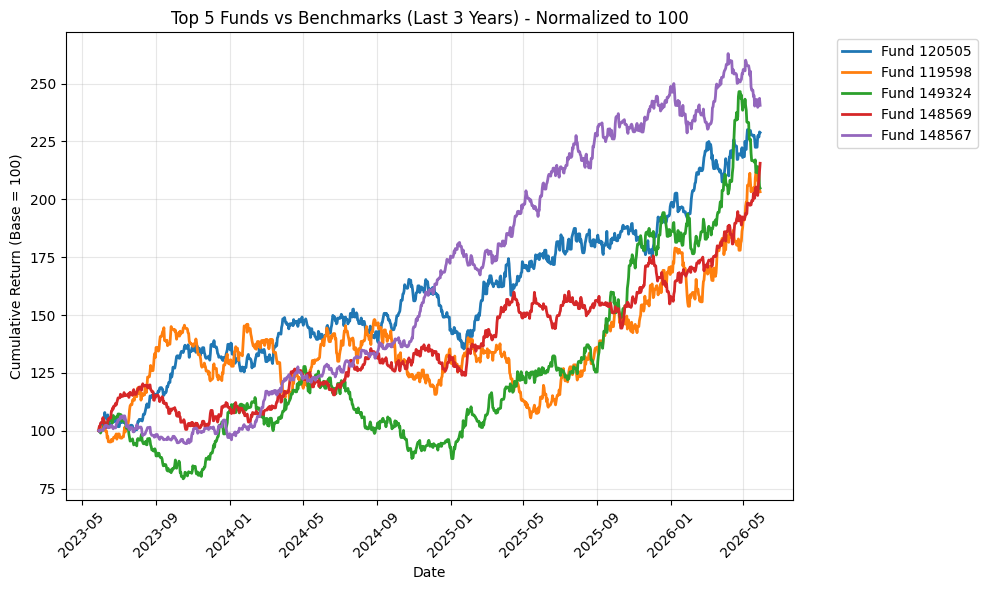

In [67]:
benchmark = pd.read_csv('../data/processed/10_benchmark_indices_cleaned.csv')
benchmark['date'] = pd.to_datetime(benchmark['date'])

# Get top 5 funds by 3Y CAGR
top_5 = cagr_df.nlargest(5, 'CAGR_3yr')['amfi_code'].tolist()

# Prepare data for last 3 years
end_date = df_nav_history['date'].max()
start_date = end_date - pd.DateOffset(years=3)

plot_data = df_nav_history[df_nav_history['date'] >= start_date].copy()

plt.figure(figsize=(10,6))

# Plot top 5 funds
for code in top_5:
    data = plot_data[plot_data['amfi_code'] == code]
    plt.plot(data['date'], data['nav'] / data['nav'].iloc[0] * 100, label=f'Fund {code}', linewidth=2)

# Plot benchmarks (assuming they exist in benchmark df)
for bench_name in ['Nifty50', 'Nifty100']:  # Adjust column names as per your benchmark file
    if bench_name in benchmark.columns:
        b_data = benchmark[benchmark['date'] >= start_date]
        plt.plot(b_data['date'], b_data[bench_name] / b_data[bench_name].iloc[0] * 100, 
                 label=bench_name, linestyle='--', linewidth=2.5)

plt.title("Top 5 Funds vs Benchmarks (Last 3 Years) - Normalized to 100")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base = 100)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/benchmark comparison chart.png")
plt.show()